In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from google.colab import files
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
import io

In [ ]:
def load_images(directory):
  images = []
  for filename in os.listdir(directory):

      img = Image.open(os.path.join(directory,filename))
      img = img.resize((150, 200))
      img = img.convert('RGB')
      img = np.array(img)/255.0
      images.append(img)
  return images

In [ ]:
car_images = load_images('/content/drive/MyDrive/Colab Notebooks/CarBike2/Car')
bike_images = load_images('/content/drive/MyDrive/Colab Notebooks/CarBike2/Bike')

/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
latih_datagen = ImageDataGenerator(
                    rotation_range=20,
                    width_shift_range=0.2,
                    height_shift_range=0.2,
                    horizontal_flip=True,
                    vertical_flip=True,
                    shear_range = 0.2,
                    zoom_range = 0.2,
                    validation_split=0.4,
                    fill_mode = 'nearest')


In [ ]:
len(car_images), len(bike_images)

(500, 500)

In [ ]:
def assign_labels(car_images, bike_images):
  car_labels = np.ones(len(car_images))
  bike_labels = np.zeros(len(bike_images))
  all_labels = np.concatenate([car_labels, bike_labels])
  all_images = car_images + bike_images
  return car_labels, bike_labels, all_images, all_labels
car_labels, bike_labels, all_images, all_labels = assign_labels(car_images, bike_images)

In [ ]:
X = np. array(all_images)
Y = np.array(all_labels)
gambar_latih, gambar_tes, label_latih, label_tes = train_test_split(X, Y, test_size = 0.4, random_state = 10)
dataset_latih = tf.data.Dataset.from_tensor_slices((gambar_latih, label_latih)).cache().prefetch(tf.data.AUTOTUNE)
dataset_tes = tf.data.Dataset.from_tensor_slices((gambar_tes, label_tes)).cache().prefetch(tf.data.AUTOTUNE)

In [ ]:
ratio = 0.1
sampel = int(ratio * len(gambar_latih))

validasi = dataset_latih.take(sampel)
latih = dataset_latih.skip(sampel)

batch = 20 #32
latih = dataset_latih.batch(batch)
tes = dataset_tes.batch(batch)
validasi = validasi.batch(batch)

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(150, 200, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(512, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)                   │ (None, 148, 198, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_60 (MaxPooling2D)      │ (None, 74, 99, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_61 (Conv2D)                   │ (None, 72, 97, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_61 (MaxPooling2D)      │ (None, 36, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_62 (Conv2D)                   │ (None, 34, 46, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_62 (MaxPooling2D)      │ (None, 17, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_63 (Conv2D)                   │ (None, 15, 21, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_63 (MaxPooling2D)      │ (None, 7, 10, 128)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_64 (Conv2D)                   │ (None, 5, 8, 512)           │         590,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_64 (MaxPooling2D)      │ (None, 2, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_12 (Flatten)                 │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 512)                 │       2,097,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,785,953 (10.63 MB)

 Trainable params: 2,785,953 (10.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer=tf.optimizers.Adam(),
              metrics=['accuracy'])

In [ ]:
model.fit(
     latih,
     steps_per_epoch=15,
     epochs=10,
     validation_data=validasi,
     validation_steps=4,
     verbose=1

    )

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 816ms/step - accuracy: 0.5066 - loss: 0.7010 - val_accuracy: 0.5500 - val_loss: 0.6818
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 899ms/step - accuracy: 0.5453 - loss: 0.6781 - val_accuracy: 0.5833 - val_loss: 0.6611
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.5833 - val_loss: 0.6611
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 27s 886ms/step - accuracy: 0.6905 - loss: 0.6332 - val_accuracy: 0.7500 - val_loss: 0.5515
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 867ms/step - accuracy: 0.7151 - loss: 0.5590 - val_accuracy: 0.8333 - val_loss: 0.4021
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.8333 - val_loss: 0.4021
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 898ms/step - accuracy: 0.8512 - loss: 0.3908 - val_accuracy: 0.9000 - val_loss: 0.1917
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 768ms/step - accuracy: 0.8198 - loss: 0.470

In [ ]:
hasil_evaluasi = model.evaluate(tes)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - accuracy: 0.8593 - loss: 0.3525


Saving Car (21).jpeg to Car (21).jpeg


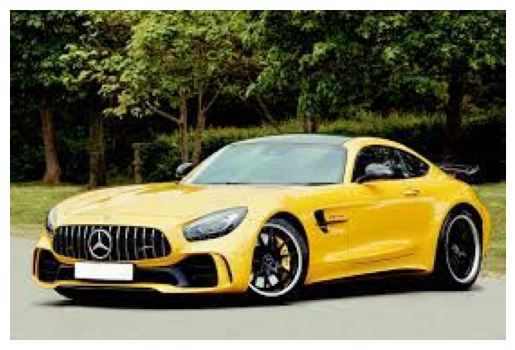

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
ini mobil


In [ ]:
def load_uploaded_image(image_bytes):
  img = Image.open(io.BytesIO(image_bytes))
  img = img.resize((150, 200))
  img_array = np.array(img)
  img_array = img_array/255.0
  return img_array

def predict_image(image_bytes):
  img_array = load_uploaded_image(image_bytes)
  img_array = np.expand_dims(img_array, axis=0)
  prediction = model.predict(img_array)
  if prediction[0][0] > 0.5:
    return "ini mobil"
  else:
    return "ini motor"

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
image_bytes = uploaded[file_name]
img = Image.open(io.BytesIO(image_bytes))

plt.imshow(img)
plt.axis('off')
plt.show()

result = predict_image(image_bytes)
print(result)